# Quant Trading Learning Notebook

This notebook is built for **learning first, profit second**.

It covers:
1. Expected value (EV)
2. Trade outcome simulation
3. Drawdown and equity curves
4. Risk of ruin intuition
5. A simple momentum backtest template

Use it like a lab bench, not a slot machine.


## 0. How to use this notebook

- Start with the EV and simulation sections.
- Change one variable at a time.
- Focus on process, not on forcing a profitable outcome.
- Keep notes on what surprised you.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 1. Expected Value

The single most important trading equation:

\[
EV = p(win) \times AvgWin - p(loss) \times AvgLoss
\]

A system can win less than 50% of the time and still be profitable.


In [ ]:
def expected_value(win_rate, avg_win, avg_loss):
    loss_rate = 1 - win_rate
    return win_rate * avg_win - loss_rate * avg_loss

win_rate = 0.42
avg_win = 2.0
avg_loss = 1.0

ev = expected_value(win_rate, avg_win, avg_loss)
print(f'Expected value per trade: {ev:.3f}R')


In [ ]:
import random

def play():
    if random.random() < 0.5:
        return 10
    else:
        return -8

results = [play() for _ in range(10000)]
print(sum(results)/len(results))

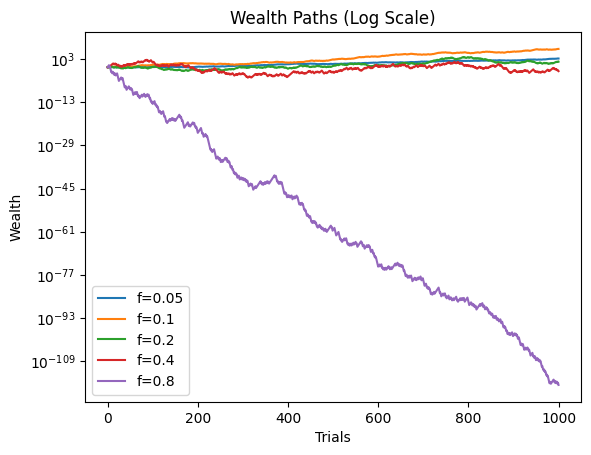

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
p = 0.6              # probability of win
win_return = 1.0     # +100% on win (double)
loss_return = -1.0   # -100% on loss (lose stake)
n_trials = 1000

# Try different bet sizes
fractions = [0.05, 0.1, 0.2, 0.4, 0.8]

plt.figure()

for f in fractions:
    wealth = 1.0
    wealth_path = [wealth]
    log_returns = []

    for _ in range(n_trials):
        if np.random.rand() < p:
            r = f * win_return
        else:
            r = f * loss_return

        wealth *= (1 + r)

        # avoid log(0)
        if wealth > 0:
            log_returns.append(np.log(1 + r))

        wealth_path.append(wealth)

    plt.plot(wealth_path, label=f"f={f}")

plt.yscale("log")
plt.legend()
plt.title("Wealth Paths (Log Scale)")
plt.xlabel("Trials")
plt.ylabel("Wealth")

plt.show()

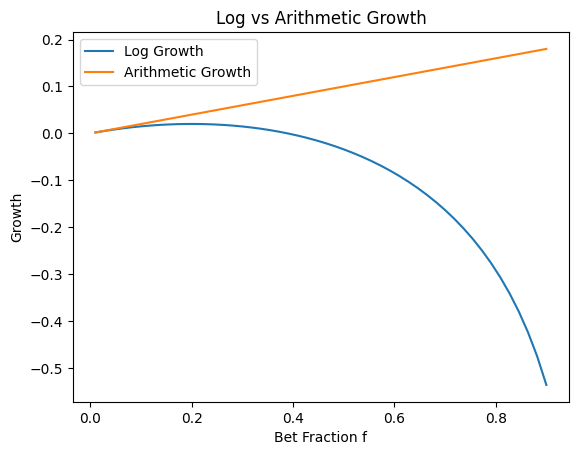

In [9]:
f_values = np.linspace(0.01, 0.9, 50)

log_growth = []
arithmetic_growth = []

for f in f_values:
    g_log = p * np.log(1 + f * win_return) + (1 - p) * np.log(1 + f * loss_return)
    g_arith = p * (f * win_return) + (1 - p) * (f * loss_return)

    log_growth.append(g_log)
    arithmetic_growth.append(g_arith)

plt.figure()
plt.plot(f_values, log_growth, label="Log Growth")
plt.plot(f_values, arithmetic_growth, label="Arithmetic Growth")
plt.legend()
plt.xlabel("Bet Fraction f")
plt.ylabel("Growth")
plt.title("Log vs Arithmetic Growth")

plt.show()

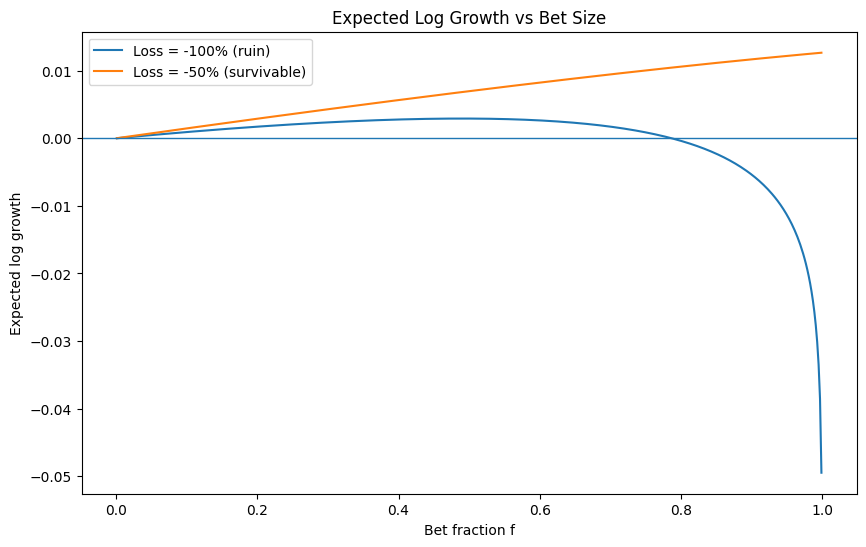

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Two scenarios:
# A: 99% chance +2%, 1% chance -100%  (ruin case)
# B: 99% chance +2%, 1% chance -50%   (survivable case)

prob_win = 0.99
win_return = 0.02

losses = [-1.0, -0.5]
labels = ["Loss = -100% (ruin)", "Loss = -50% (survivable)"]

f_values = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(10, 6))

for loss_return, label in zip(losses, labels):
    log_growth = []

    for f in f_values:
        # Wealth multiplier each round:
        # win:  1 + f * win_return
        # loss: 1 + f * loss_return

        win_mult = 1 + f * win_return
        loss_mult = 1 + f * loss_return

        # If multiplier is <= 0, log is undefined -> treat as -inf
        if win_mult <= 0 or loss_mult <= 0:
            g = -np.inf
        else:
            g = prob_win * np.log(win_mult) + (1 - prob_win) * np.log(loss_mult)

        log_growth.append(g)

    plt.plot(f_values, log_growth, label=label)

plt.axhline(0, linewidth=1)
plt.xlabel("Bet fraction f")
plt.ylabel("Expected log growth")
plt.title("Expected Log Growth vs Bet Size")
plt.legend()
plt.show()



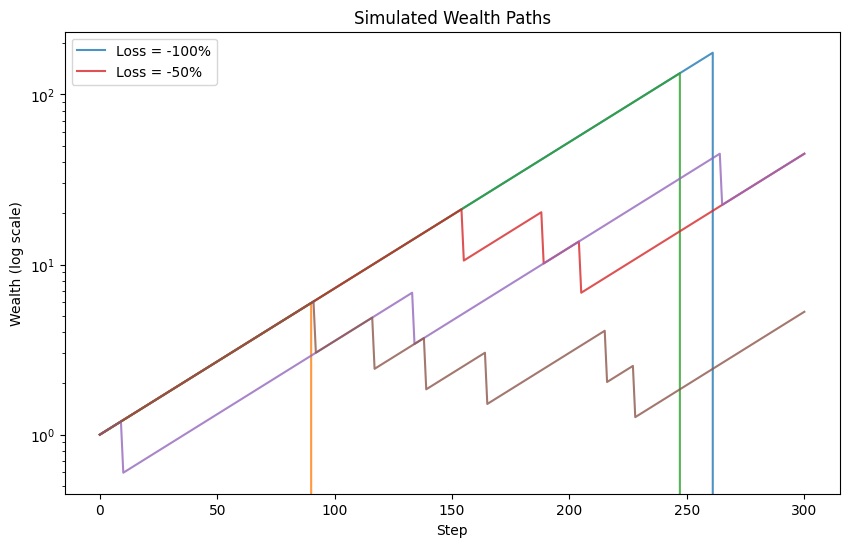

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_path(prob_win, win_return, loss_return, f, n_steps=300):
    wealth = [1.0]
    for _ in range(n_steps):
        if np.random.rand() < prob_win:
            r = win_return
        else:
            r = loss_return
        wealth.append(wealth[-1] * (1 + f * r))
    return np.array(wealth)

prob_win = 0.99
win_return = 0.02

cases = [
    (-1.0, "Loss = -100%"),
    (-0.5, "Loss = -50%")
]

f = 1.0  # full exposure to show the effect clearly

plt.figure(figsize=(10, 6))

for loss_return, label in cases:
    for i in range(3):
        path = simulate_path(prob_win, win_return, loss_return, f, n_steps=300)
        plt.plot(path, alpha=0.8, label=label if i == 0 else None)

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Wealth (log scale)")
plt.title("Simulated Wealth Paths")
plt.legend()
plt.show()

In [16]:
import random

def strategy_A():
    return 3 if random.random() < 0.4 else -1

def strategy_B():
    return 1 if random.random() < 0.8 else -4

def run(strategy, n=10000):
    results = [strategy() for _ in range(n)]
    return sum(results)/n

print("A:", run(strategy_A))
print("B:", run(strategy_B))

A: 0.5704
B: 0.0155


In [17]:
import numpy as np

# Example discrete return distribution
returns = np.array([0.10, -0.10])   # +10%, -10%
probs = np.array([0.5, 0.5])

mu = np.sum(probs * returns)
var = np.sum(probs * (returns - mu)**2)

exact = np.sum(probs * np.log(1 + returns))
approx1 = mu - 0.5 * var
approx2 = mu - 0.5 * var - 0.5 * mu**2

print("mu:", mu)
print("var:", var)
print("Exact E[log(1+r)]:", exact)
print("Approx mu - var/2:", approx1)
print("Approx mu - var/2 - mu^2/2:", approx2)

mu: 0.0
var: 0.010000000000000002
Exact E[log(1+r)]: -0.005025167926750673
Approx mu - var/2: -0.005000000000000001
Approx mu - var/2 - mu^2/2: -0.005000000000000001


Sharpe A: 0.49617097897559126
Sharpe B: 0.5130414307866819
Sharpe Portfolio: 0.7166774129655972


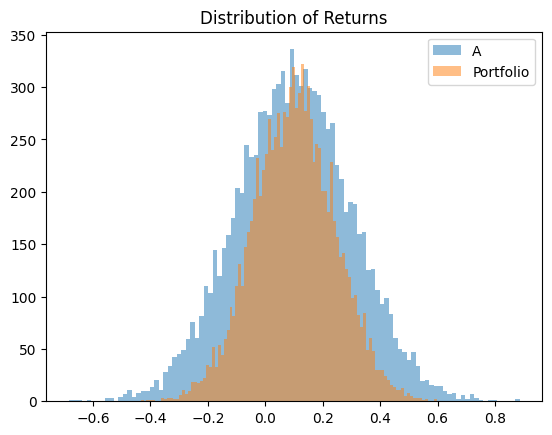

Correlation: 0
Sharpe Portfolio: 0.6912538552987806


In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 10000

# Strategy parameters
mu = 0.10
sigma = 0.20

# Generate returns
A = np.random.normal(mu, sigma, n)
B = np.random.normal(mu, sigma, n)

# Portfolio (50/50)
portfolio = 0.5 * A + 0.5 * B

# Function to compute Sharpe
def sharpe(x):
    return np.mean(x) / np.std(x)

print("Sharpe A:", sharpe(A))
print("Sharpe B:", sharpe(B))
print("Sharpe Portfolio:", sharpe(portfolio))

plt.hist(A, bins=100, alpha=0.5, label="A")
plt.hist(portfolio, bins=100, alpha=0.5, label="Portfolio")
plt.legend()
plt.title("Distribution of Returns")
plt.show()

rho = 0  # try 1.0, 0.5, 0.0, -0.5

cov = [[sigma**2, rho*sigma**2],
       [rho*sigma**2, sigma**2]]

A, B = np.random.multivariate_normal([mu, mu], cov, n).T

portfolio = 0.5 * A + 0.5 * B

print("Correlation:", rho)
print("Sharpe Portfolio:", sharpe(portfolio))


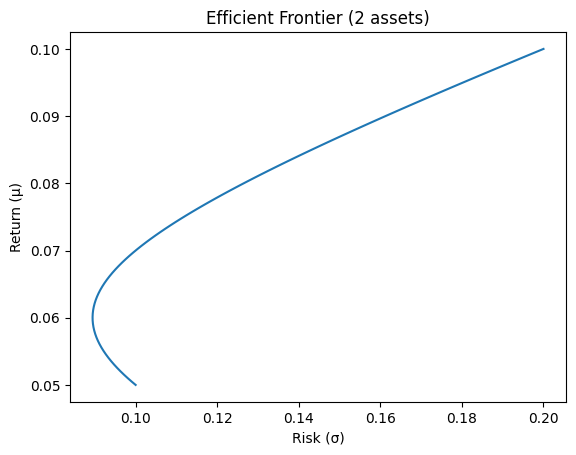

In [3]:
import numpy as np
import matplotlib.pyplot as plt

mu_A, sigma_A = 0.10, 0.20
mu_B, sigma_B = 0.05, 0.10
rho = 0

w_values = np.linspace(0, 1, 100)

mu_P = []
sigma_P = []

for w in w_values:
    mu = w*mu_A + (1-w)*mu_B
    
    var = (w**2)*(sigma_A**2) + ((1-w)**2)*(sigma_B**2) \
          + 2*w*(1-w)*rho*sigma_A*sigma_B
    
    mu_P.append(mu)
    sigma_P.append(np.sqrt(var))

plt.plot(sigma_P, mu_P)
plt.xlabel("Risk (σ)")
plt.ylabel("Return (μ)")
plt.title("Efficient Frontier (2 assets)")
plt.show()

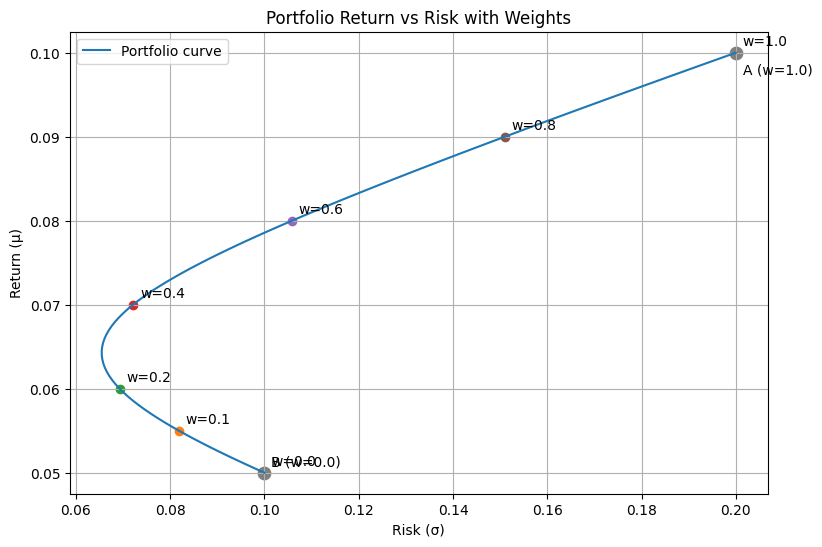

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu_A, sigma_A = 0.10, 0.20
mu_B, sigma_B = 0.05, 0.10
rho = -0.5

# Weights for asset A
w_values = np.linspace(0, 1, 101)

mu_P = []
sigma_P = []

for w in w_values:
    mu = w * mu_A + (1 - w) * mu_B
    var = (
        (w**2) * sigma_A**2
        + ((1 - w)**2) * sigma_B**2
        + 2 * w * (1 - w) * rho * sigma_A * sigma_B
    )
    mu_P.append(mu)
    sigma_P.append(np.sqrt(var))

mu_P = np.array(mu_P)
sigma_P = np.array(sigma_P)

# Plot the full curve
plt.figure(figsize=(9, 6))
plt.plot(sigma_P, mu_P, label="Portfolio curve")

# Mark and annotate selected weights
selected_weights = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

for w in selected_weights:
    mu = w * mu_A + (1 - w) * mu_B
    var = (
        (w**2) * sigma_A**2
        + ((1 - w)**2) * sigma_B**2
        + 2 * w * (1 - w) * rho * sigma_A * sigma_B
    )
    sigma = np.sqrt(var)

    plt.scatter(sigma, mu)
    plt.annotate(
        f"w={w:.1f}",
        (sigma, mu),
        textcoords="offset points",
        xytext=(5, 5)
    )

# Also label the endpoints clearly
plt.scatter([sigma_A, sigma_B], [mu_A, mu_B], s=80)
plt.annotate("A (w=1.0)", (sigma_A, mu_A), textcoords="offset points", xytext=(5, -15))
plt.annotate("B (w=0.0)", (sigma_B, mu_B), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Risk (σ)")
plt.ylabel("Return (μ)")
plt.title("Portfolio Return vs Risk with Weights")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
import numpy as np

sigma_A = 0.20
sigma_B = 0.10
rho = 0

w_values = np.linspace(0, 1, 1000)

variances = []

for w in w_values:
    var = (
        (w**2)*sigma_A**2 +
        ((1-w)**2)*sigma_B**2 +
        2*w*(1-w)*rho*sigma_A*sigma_B
    )
    variances.append(var)

w_min = w_values[np.argmin(variances)]

print("Minimum variance weight (A):", w_min)

Minimum variance weight (A): 0.20020020020020018


Max Sharpe weight in A: 0.3843843843843844
Max Sharpe: 1.2806247022910335


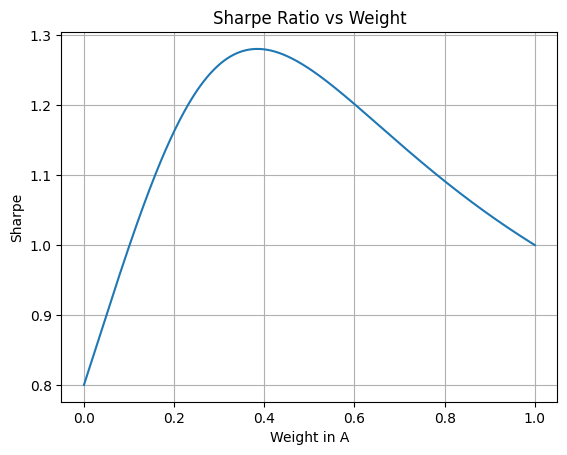

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mu_A, sigma_A = 0.10, 0.10
mu_B, sigma_B = 0.04, 0.05
rho = 0.0

w_values = np.linspace(0, 1, 1000)

mu_list = []
sigma_list = []
sharpe_list = []

for w in w_values:
    mu = w * mu_A + (1 - w) * mu_B
    var = (
        (w**2) * sigma_A**2
        + ((1 - w)**2) * sigma_B**2
        + 2 * w * (1 - w) * rho * sigma_A * sigma_B
    )
    sigma = np.sqrt(var)
    sharpe = mu / sigma

    mu_list.append(mu)
    sigma_list.append(sigma)
    sharpe_list.append(sharpe)

w_star = w_values[np.argmax(sharpe_list)]

print("Max Sharpe weight in A:", w_star)
print("Max Sharpe:", max(sharpe_list))
plt.plot(w_values, sharpe_list)
plt.xlabel("Weight in A")
plt.ylabel("Sharpe")
plt.title("Sharpe Ratio vs Weight")
plt.grid(True)
plt.show()

Estimated daily mean returns:
Strategy_A   -0.000102
Strategy_B    0.000457
Strategy_C    0.000401
dtype: float64

Estimated daily vols:
Strategy_A    0.009733
Strategy_B    0.006007
Strategy_C    0.007937
dtype: float64

Estimated covariance matrix:
            Strategy_A  Strategy_B  Strategy_C
Strategy_A    0.000095    0.000013   -0.000004
Strategy_B    0.000013    0.000036    0.000007
Strategy_C   -0.000004    0.000007    0.000063

Equal-weight portfolio:
Weights: [0.33333333 0.33333333 0.33333333]
Return: 0.000252, Vol: 0.005019, Sharpe: 0.0502

Minimum-variance portfolio:
w_A       0.181841
w_B       0.504663
w_C       0.313496
return    0.000338
vol       0.004769
sharpe    0.070833
Name: 659, dtype: float64

Maximum-Sharpe portfolio:
w_A       0.004771
w_B       0.727656
w_C       0.267572
return    0.000439
vol       0.005142
sharpe    0.085473
Name: 3906, dtype: float64

Original Max Sharpe Weights:
w_A    0.004771
w_B    0.727656
w_C    0.267572
Name: 3906, dtype: float64

N

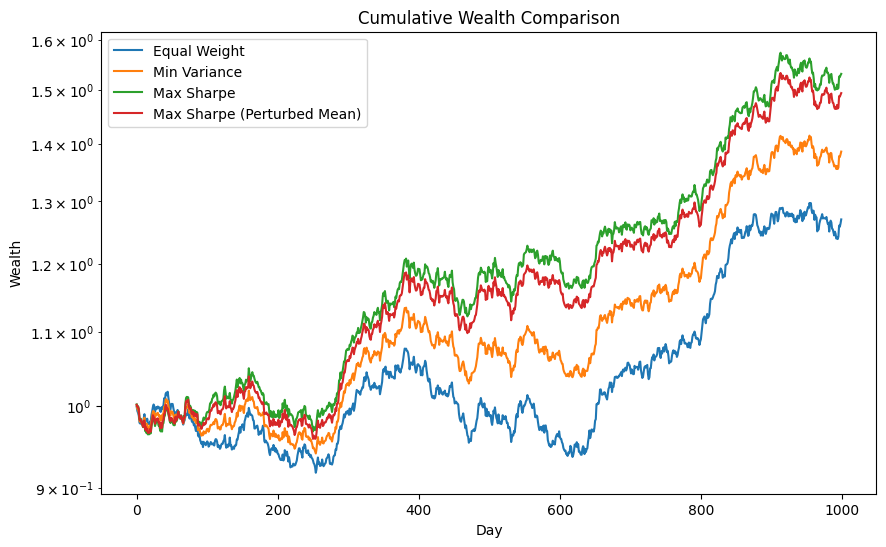

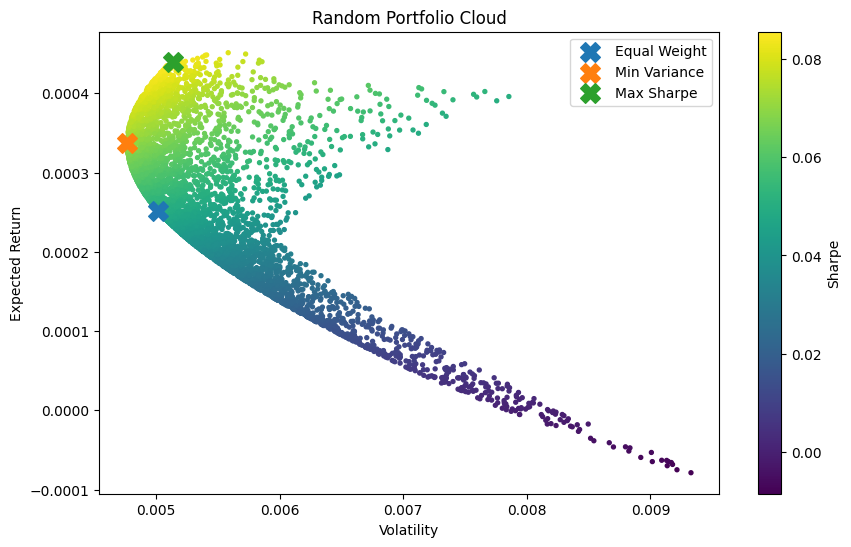

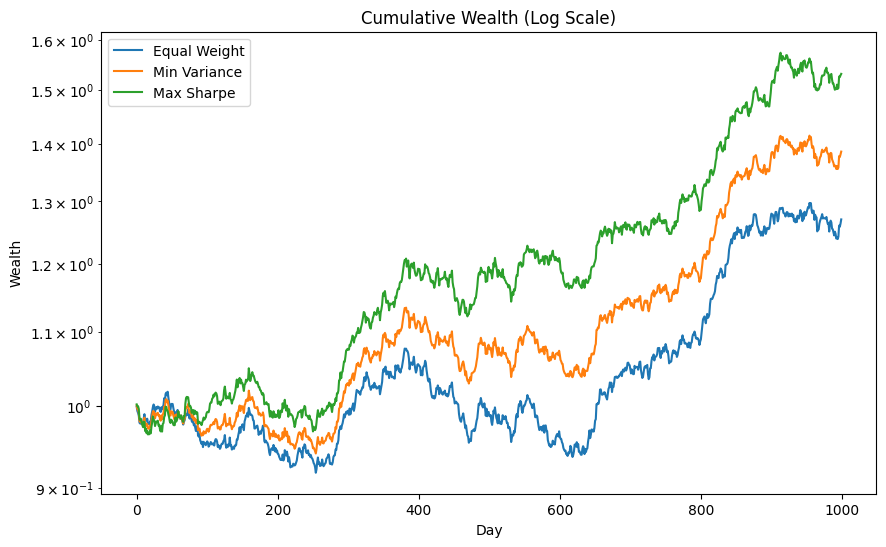

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# 1) Simulate 3 strategy return streams
# -----------------------------
n_days = 1000

# Daily means
mu = np.array([0.0005, 0.0003, 0.0004])

# Daily volatilities
vol = np.array([0.01, 0.006, 0.008])

# Correlation matrix
corr = np.array([
    [1.0,  0.2, -0.1],
    [0.2,  1.0,  0.1],
    [-0.1, 0.1,  1.0]
])

# Convert vol + corr into covariance matrix
cov = np.outer(vol, vol) * corr

# Simulate daily returns
returns = np.random.multivariate_normal(mu, cov, size=n_days)

df = pd.DataFrame(returns, columns=["Strategy_A", "Strategy_B", "Strategy_C"])

# -----------------------------
# 2) Estimate mean / vol / cov
# -----------------------------
mean_returns = df.mean()
cov_matrix = df.cov()
vols = df.std()

print("Estimated daily mean returns:")
print(mean_returns)
print("\nEstimated daily vols:")
print(vols)
print("\nEstimated covariance matrix:")
print(cov_matrix)

# -----------------------------
# 3) Portfolio helper functions
# -----------------------------
def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_vol(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_sharpe(weights, mean_returns, cov_matrix, rf=0.0):
    port_ret = portfolio_return(weights, mean_returns)
    port_vol = portfolio_vol(weights, cov_matrix)
    return (port_ret - rf) / port_vol

# -----------------------------
# 4) Random portfolios
# -----------------------------
n_portfolios = 5000
results = []

for _ in range(n_portfolios):
    w = np.random.random(3)
    w = w / w.sum()

    r = portfolio_return(w, mean_returns)
    v = portfolio_vol(w, cov_matrix)
    s = portfolio_sharpe(w, mean_returns, cov_matrix)

    results.append([w[0], w[1], w[2], r, v, s])

results_df = pd.DataFrame(
    results,
    columns=["w_A", "w_B", "w_C", "return", "vol", "sharpe"]
)

# -----------------------------
# 5) Equal-weight portfolio
# -----------------------------
w_eq = np.array([1/3, 1/3, 1/3])
eq_ret = portfolio_return(w_eq, mean_returns)
eq_vol = portfolio_vol(w_eq, cov_matrix)
eq_sharpe = portfolio_sharpe(w_eq, mean_returns, cov_matrix)

# -----------------------------
# 6) Find minimum variance and max Sharpe
# -----------------------------
min_var_row = results_df.loc[results_df["vol"].idxmin()]
max_sharpe_row = results_df.loc[results_df["sharpe"].idxmax()]

print("\nEqual-weight portfolio:")
print(f"Weights: {w_eq}")
print(f"Return: {eq_ret:.6f}, Vol: {eq_vol:.6f}, Sharpe: {eq_sharpe:.4f}")

print("\nMinimum-variance portfolio:")
print(min_var_row)

print("\nMaximum-Sharpe portfolio:")
print(max_sharpe_row)

def cumulative_curve(weights, df):
    port_rets = df @ weights
    return (1 + port_rets).cumprod()

# -----------------------------
# 6b) Perturb mean and recompute max Sharpe
# -----------------------------
mean_returns_perturbed = mean_returns.copy()
mean_returns_perturbed["Strategy_A"] += 0.0003  # small change

# recompute Sharpe for all portfolios using new mean
sharpe_perturbed = []

for i, row in results_df.iterrows():
    w = np.array([row["w_A"], row["w_B"], row["w_C"]])
    
    s = portfolio_sharpe(w, mean_returns_perturbed, cov_matrix)
    sharpe_perturbed.append(s)

results_df["sharpe_perturbed"] = sharpe_perturbed

# find new max Sharpe
max_sharpe_perturbed_row = results_df.loc[results_df["sharpe_perturbed"].idxmax()]

print("\nOriginal Max Sharpe Weights:")
print(max_sharpe_row[["w_A", "w_B", "w_C"]])

print("\nNew Max Sharpe Weights (after small mean change):")
print(max_sharpe_perturbed_row[["w_A", "w_B", "w_C"]])

# Cumulative curve for perturbed max Sharpe
cum_maxsharpe_perturbed = cumulative_curve(
    np.array([
        max_sharpe_perturbed_row["w_A"],
        max_sharpe_perturbed_row["w_B"],
        max_sharpe_perturbed_row["w_C"]
    ]),
    df
)
cum_eq = cumulative_curve(w_eq, df)
cum_minvar = cumulative_curve(
    np.array([min_var_row["w_A"], min_var_row["w_B"], min_var_row["w_C"]]), df
)
cum_maxsharpe = cumulative_curve(
    np.array([max_sharpe_row["w_A"], max_sharpe_row["w_B"], max_sharpe_row["w_C"]]), df
)

plt.figure(figsize=(10, 6))
plt.plot(cum_eq, label="Equal Weight")
plt.plot(cum_minvar, label="Min Variance")
plt.plot(cum_maxsharpe, label="Max Sharpe")
plt.plot(cum_maxsharpe_perturbed, label="Max Sharpe (Perturbed Mean)")
plt.yscale("log")
plt.title("Cumulative Wealth Comparison")
plt.xlabel("Day")
plt.ylabel("Wealth")
plt.legend()
plt.show()


# -----------------------------
# 7) Plot risk-return scatter
# -----------------------------
plt.figure(figsize=(10, 6))
sc = plt.scatter(results_df["vol"], results_df["return"], c=results_df["sharpe"], s=8)
plt.colorbar(sc, label="Sharpe")

plt.scatter(eq_vol, eq_ret, marker="X", s=200, label="Equal Weight")
plt.scatter(min_var_row["vol"], min_var_row["return"], marker="X", s=200, label="Min Variance")
plt.scatter(max_sharpe_row["vol"], max_sharpe_row["return"], marker="X", s=200, label="Max Sharpe")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Random Portfolio Cloud")
plt.legend()
plt.show()

# -----------------------------
# 8) Plot cumulative returns
# -----------------------------


cum_eq = cumulative_curve(w_eq, df)
cum_minvar = cumulative_curve(
    np.array([min_var_row["w_A"], min_var_row["w_B"], min_var_row["w_C"]]), df
)
cum_maxsharpe = cumulative_curve(
    np.array([max_sharpe_row["w_A"], max_sharpe_row["w_B"], max_sharpe_row["w_C"]]), df
)

plt.figure(figsize=(10, 6))
plt.plot(cum_eq, label="Equal Weight")
plt.plot(cum_minvar, label="Min Variance")
plt.plot(cum_maxsharpe, label="Max Sharpe")
plt.yscale("log")
plt.title("Cumulative Wealth (Log Scale)")
plt.xlabel("Day")
plt.ylabel("Wealth")
plt.legend()
plt.show()

In [4]:
split = len(df) // 2
df_train = df.iloc[:split]
df_test = df.iloc[split:]

print(len(df_train), len(df_test))

mean_train = df_train.mean()
cov_train = df_train.cov()
vol_train = df_train.std()

# 3) Portfolio helper functions
def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_vol(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_sharpe(weights, mean_returns, cov_matrix, rf=0.0):
    port_ret = portfolio_return(weights, mean_returns)
    port_vol = portfolio_vol(weights, cov_matrix)
    return (port_ret - rf) / port_vol

# 4) Random portfolios
n_portfolios_train = 5000
results_train = []

n_assets = df_train.shape[1]

for _ in range(n_portfolios_train):
    w = np.random.random(n_assets)
    w = w / w.sum()

    r = portfolio_return(w, mean_train)
    v = portfolio_vol(w, cov_train)
    s = portfolio_sharpe(w, mean_train, cov_train)

    results_train.append([*w, r, v, s])

results_train_df = pd.DataFrame(
    results_train,
    columns=["w_A", "w_B", "w_C", "return", "vol", "sharpe"]
)

# 5) Equal-weight portfolio
w_eq = np.ones(n_assets) / n_assets
eq_ret = portfolio_return(w_eq, mean_train)
eq_vol = portfolio_vol(w_eq, cov_train)
eq_sharpe = portfolio_sharpe(w_eq, mean_train, cov_train)

# 6) Find minimum variance and max Sharpe
min_var_row = results_train_df.loc[results_train_df["vol"].idxmin()]
max_sharpe_row = results_train_df.loc[results_train_df["sharpe"].idxmax()]

print("\nEqual-weight portfolio:")
print(f"Weights: {w_eq}")
print(f"Return: {eq_ret:.6f}, Vol: {eq_vol:.6f}, Sharpe: {eq_sharpe:.4f}")

print("\nMinimum-variance portfolio:")
print(min_var_row)

print("\nMaximum-Sharpe portfolio:")
print(max_sharpe_row)

500 500

Equal-weight portfolio:
Weights: [0.33333333 0.33333333 0.33333333]
Return: -0.000004, Vol: 0.004893, Sharpe: -0.0007

Minimum-variance portfolio:
w_A       0.207014
w_B       0.467168
w_C       0.325819
return    0.000139
vol       0.004709
sharpe    0.029504
Name: 1949, dtype: float64

Maximum-Sharpe portfolio:
w_A       0.002319
w_B       0.690640
w_C       0.307041
return    0.000370
vol       0.005178
sharpe    0.071538
Name: 1006, dtype: float64


Try changing:
- `win_rate`
- `avg_win`
- `avg_loss`

Ask yourself: what combinations produce positive EV?


## 2. Simulate a trading system

We simulate many trades with a fixed win rate and payoff structure.
This helps you feel the emotional weather of randomness.


In [ ]:
def simulate_trades(n_trades=200, win_rate=0.42, avg_win=2.0, avg_loss=1.0, risk_per_trade=1.0, seed=42):
    rng = np.random.default_rng(seed)
    wins = rng.random(n_trades) < win_rate
    pnl_r = np.where(wins, avg_win * risk_per_trade, -avg_loss * risk_per_trade)
    equity_r = pnl_r.cumsum()
    df = pd.DataFrame({
        'trade_number': np.arange(1, n_trades + 1),
        'win': wins,
        'pnl_r': pnl_r,
        'equity_r': equity_r
    })
    return df

sim_df = simulate_trades()
sim_df.head()


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(sim_df['trade_number'], sim_df['equity_r'])
plt.xlabel('Trade Number')
plt.ylabel('Equity (R)')
plt.title('Simulated Equity Curve')
plt.grid(True, alpha=0.3)
plt.show()


## 3. Drawdown

A strategy can have positive EV and still punch you in the face for 20 trades in a row.
Drawdown is the part traders underestimate until it visits them personally.


In [ ]:
def add_drawdown(df):
    df = df.copy()
    df['peak_equity_r'] = df['equity_r'].cummax()
    df['drawdown_r'] = df['equity_r'] - df['peak_equity_r']
    return df

dd_df = add_drawdown(sim_df)
print('Max drawdown (R):', dd_df['drawdown_r'].min())
dd_df.tail()


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(dd_df['trade_number'], dd_df['drawdown_r'])
plt.xlabel('Trade Number')
plt.ylabel('Drawdown (R)')
plt.title('Drawdown Curve')
plt.grid(True, alpha=0.3)
plt.show()


## 4. Multiple simulations

One backtest path can flatter you. Many paths give you humility.


In [ ]:
def run_many_simulations(n_sims=200, n_trades=200, win_rate=0.42, avg_win=2.0, avg_loss=1.0):
    ending_equities = []
    max_drawdowns = []
    for i in range(n_sims):
        df = simulate_trades(n_trades=n_trades, win_rate=win_rate, avg_win=avg_win, avg_loss=avg_loss, seed=i)
        df = add_drawdown(df)
        ending_equities.append(df['equity_r'].iloc[-1])
        max_drawdowns.append(df['drawdown_r'].min())
    return pd.DataFrame({
        'ending_equity_r': ending_equities,
        'max_drawdown_r': max_drawdowns
    })

many = run_many_simulations()
many.describe()


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(many['ending_equity_r'], bins=25)
plt.xlabel('Ending Equity (R)')
plt.ylabel('Frequency')
plt.title('Distribution of Ending Outcomes Across Simulations')
plt.grid(True, alpha=0.3)
plt.show()


## 5. Position sizing in dollars

Now convert abstract `R` into money.
With a $2,000 learning account, keep risk tiny.

Suggested training rule:
- Risk 0.5% to 1.0% per trade in the beginning
- For $2,000 that is roughly $10 to $20 per trade


In [ ]:
account_size = 2000
risk_pct = 0.01
risk_dollars = account_size * risk_pct
print(f'Risk per trade: ${risk_dollars:.2f}')


## 6. Simple risk of ruin intuition

This is not a perfect institutional model. It is a beginner-friendly intuition builder.
We estimate how often a strategy hits a capital floor.


In [ ]:
def estimate_ruin_probability(n_sims=1000, n_trades=300, starting_capital=2000, risk_pct=0.01,
                              win_rate=0.42, avg_win=2.0, avg_loss=1.0, ruin_floor=1400):
    ruined = 0
    for i in range(n_sims):
        capital = starting_capital
        rng = np.random.default_rng(i)
        for _ in range(n_trades):
            risk = capital * risk_pct
            if rng.random() < win_rate:
                capital += avg_win * risk
            else:
                capital -= avg_loss * risk
            if capital <= ruin_floor:
                ruined += 1
                break
    return ruined / n_sims

ruin_prob = estimate_ruin_probability()
print(f'Estimated probability of hitting the ruin floor: {ruin_prob:.2%}')


Try changing:
- `risk_pct`
- `win_rate`
- `avg_win`
- `ruin_floor`

The lesson usually arrives fast: even decent systems can be wrecked by oversized risk.


## 7. Load your own price data

Export OHLC data from your charting platform or broker into a CSV.
Expected columns:
- `Date`
- `Open`
- `High`
- `Low`
- `Close`

Then update the file path below.


In [ ]:
# Example:
# df = pd.read_csv('your_data.csv', parse_dates=['Date'])
# df = df.sort_values('Date').reset_index(drop=True)
# df.head()


## 8. Simple momentum backtest template

This is deliberately simple.
Rule idea:
- Buy when today's close breaks the highest close of the past 5 days
- Exit after 3 days or at a stop

This is not a production strategy. It is a math classroom wearing market clothes.


In [ ]:
def simple_momentum_backtest(df, lookback=5, hold_days=3):
    data = df.copy()
    data['prior_5d_high_close'] = data['Close'].shift(1).rolling(lookback).max()
    data['entry_signal'] = data['Close'] > data['prior_5d_high_close']

    trades = []
    for i in range(len(data) - hold_days):
        if data.loc[i, 'entry_signal']:
            entry_date = data.loc[i + 1, 'Date'] if i + 1 < len(data) else pd.NaT
            entry_price = data.loc[i + 1, 'Open'] if i + 1 < len(data) else np.nan
            exit_idx = i + hold_days
            exit_date = data.loc[exit_idx, 'Date']
            exit_price = data.loc[exit_idx, 'Close']
            ret = (exit_price / entry_price) - 1
            trades.append({
                'entry_date': entry_date,
                'exit_date': exit_date,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'return_pct': ret
            })
    return pd.DataFrame(trades)

# Example use after loading data:
# trades = simple_momentum_backtest(df)
# trades.head()


## 9. Evaluate your backtest

You are not looking for magic.
You are looking for:
- win rate
- average win
- average loss
- EV
- worst drawdown
- number of trades


In [ ]:
def evaluate_trade_returns(trades_df):
    if trades_df.empty:
        return {'message': 'No trades generated.'}
    wins = trades_df[trades_df['return_pct'] > 0]['return_pct']
    losses = trades_df[trades_df['return_pct'] <= 0]['return_pct']
    win_rate = len(wins) / len(trades_df)
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = abs(losses.mean()) if len(losses) > 0 else 0
    ev = expected_value(win_rate, avg_win, avg_loss)
    equity = (1 + trades_df['return_pct']).cumprod()
    peak = equity.cummax()
    drawdown = equity / peak - 1
    return {
        'n_trades': len(trades_df),
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'expected_value_per_trade': ev,
        'max_drawdown': drawdown.min()
    }

# Example:
# stats = evaluate_trade_returns(trades)
# stats


## 10. The math roadmap you should study alongside this

### Month 1
- Probability basics
- Conditional probability
- Expected value
- Variance and standard deviation

### Month 2
- Sampling
- Bias and overfitting
- Distributions and fat tails
- Monte Carlo simulation

### Month 3
- Correlation vs causation
- Hypothesis testing
- Time series basics
- Autocorrelation

### Month 4 and beyond
- Regime changes
- Position sizing
- Drawdown mathematics
- Basic optimization and validation


## 11. Your operating rules for the first 6 months

1. No revenge trading.
2. No increasing size after a loss.
3. No strategy changes mid-streak without review.
4. Review weekly, not emotionally after every candle.
5. Treat the first $2,000 as tuition, not identity.
